In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import yaml
import time
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 222 ms, sys: 503 ms, total: 726 ms
Wall time: 2.07 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

In [3]:
# summarize number of isoforms per cluster
transcript_read_threshold = 10 # minimum number of counts per cluster

results = []

for group_name, group in adata.obs.groupby('subgroup', observed=True):
    tmp = adata[group.index, :].copy()
    var = tmp.var.copy()

    # get the transcripts
    var['reads_per_transcript'] = np.ravel(tmp.X.sum(axis=0))
    var = var[var['gene_type'] == 'protein_coding']
    var = var[var['transcript_type'] == 'protein_coding']
    var['transcript_pass'] = var['reads_per_transcript'] > transcript_read_threshold
    
    var = var.groupby('gene_name')['transcript_pass'].sum()
    var = var.map(lambda x: "NE" if x == 0 else "single" if x == 1 else "multi")
    var.name = group_name
    results.append(var)

# save sankey inputs
outpath = "/scratch/indikar_root/indikar1/shared_data/for_joshua/sankey_inputs.csv"
results = pd.concat(results, axis=1)
results = results.reset_index()
results.to_csv(outpath, index=False)
results.head()

,gene_name,C1,C2,C3,CLP,HSC,LMPP,intial,progenitors
0,A1BG,NE,NE,NE,NE,NE,NE,NE,NE
1,A1BG-AS1,NE,NE,NE,NE,NE,NE,NE,NE
2,A2M,single,single,single,NE,NE,NE,single,NE
3,A2M-AS1,NE,NE,NE,NE,NE,NE,NE,NE
4,A2ML1,NE,NE,NE,NE,single,single,NE,single


# sankey plot

pdf.shape=(15038, 5)
           intial      C2      C3 progenitors     HSC
gene_name                                            
A2M        single  single  single          NE      NE
A2ML1          NE      NE      NE      single  single
A4GALT      multi   multi   multi          NE      NE
A4GNT      single      NE  single          NE      NE
AAAS        multi   multi   multi       multi  single
AACS       single  single  single      single  single
AADAC          NE  single  single          NE      NE
AADAT       multi  single  single       multi   multi
AAGAB       multi   multi   multi       multi   multi
AAK1        multi   multi   multi      single  single
AAMDC       multi   multi   multi       multi   multi
AAMP        multi   multi   multi       multi   multi
AANAT          NE      NE      NE      single      NE
AAR2        multi  single  single       multi   multi
AARD       single  single      NE      single  single


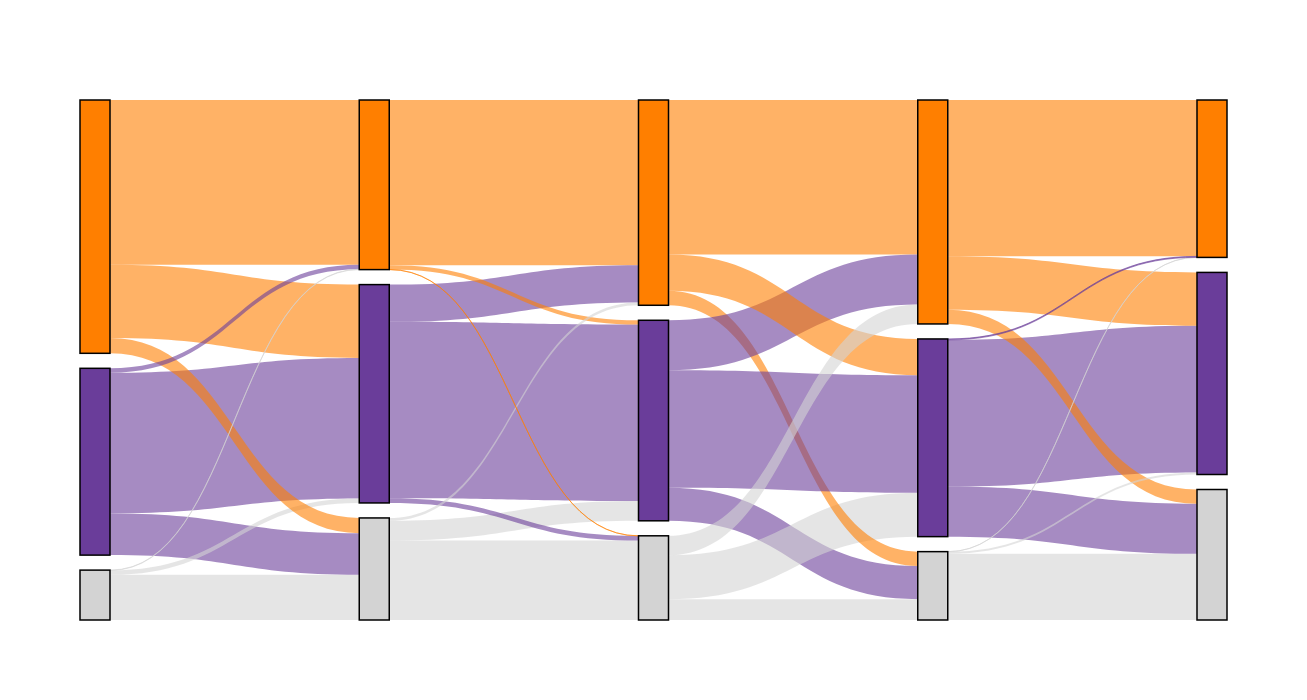

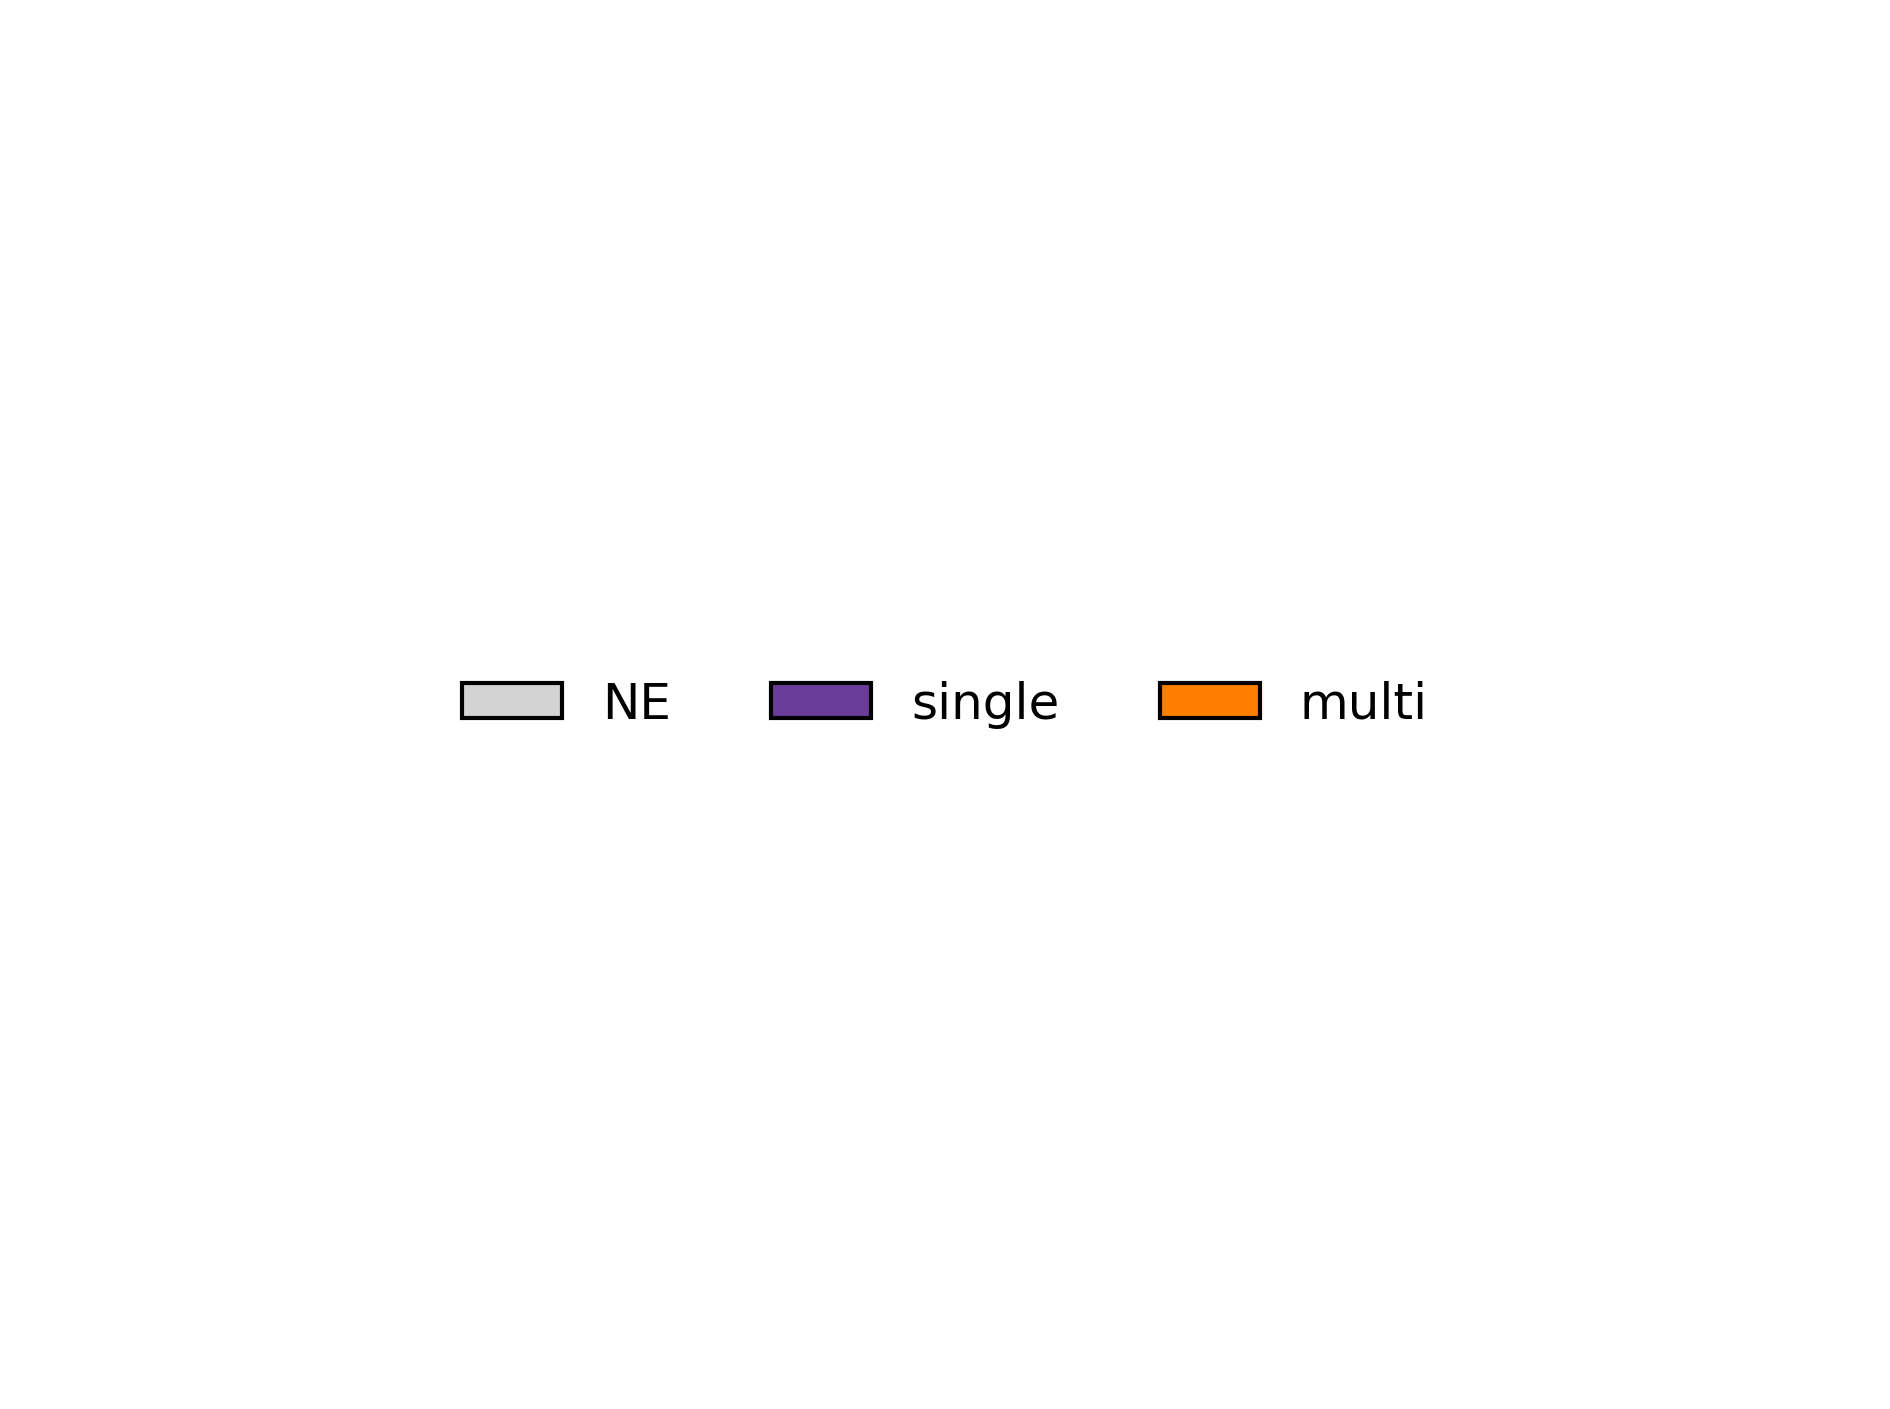

In [4]:
pdf = results.copy()
pdf = pdf.set_index('gene_name')
pdf = pdf[['intial', 'C2', 'C3', 'progenitors', 'HSC']]

# drop rows with all NE
mask = pdf.ne("NE").any(axis=1)
pdf = pdf[mask]
print(f"{pdf.shape=}")
print(pdf.head(15).to_string())

# Flatten transitions: from one stage to the next
stages = pdf.columns.tolist()
labels = ['NE', 'single', 'multi']
label_indices = {label: i for i, label in enumerate(labels)}
colors = {
    "NE" : '#d3d3d3',
    "single": '#6a3d9a',  # purple
    "multi": '#ff7f00',   # orange
}

def hex_to_rgba(hex_color, alpha=0.4):
    from matplotlib.colors import to_rgba
    rgba = to_rgba(hex_color, alpha)
    return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"


# Desired vertical sort order (top to bottom)
label_order = ['multi', 'single', 'NE']

# Build nodes in consistent stage-wise order
nodes = []
node_lookup = {}
idx = 0
for stage in stages:
    for label in label_order:
        node_name = f"{stage}_{label}"
        nodes.append(node_name)
        node_lookup[node_name] = idx
        idx += 1

source = []
target = []
value = []
link_color = []

for i in range(len(stages) - 1):
    src_stage = stages[i]
    tgt_stage = stages[i + 1]
    
    transitions = pdf[[src_stage, tgt_stage]].values.tolist()
    counts = Counter(tuple(pair) for pair in transitions)
    
    for (src_val, tgt_val), count in counts.items():
        if src_val in labels and tgt_val in labels:
            src_idx = node_lookup[f"{src_stage}_{src_val}"]
            tgt_idx = node_lookup[f"{tgt_stage}_{tgt_val}"]
            source.append(src_idx)
            target.append(tgt_idx)
            value.append(count)
            link_color.append(hex_to_rgba(colors[src_val], alpha=0.6)),

# Sankey plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=30,
        line=dict(color="black", width=1.5),
        # label=[node.split('_')[0] for node in nodes],  # Strip stage
        color=[colors[node.split('_')[1]] for node in nodes]
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_color,
    ))])

fig.update_layout(
    font_size=20,
    height=700,
    width=1000,
)
fig.show()


# Create legend handles
legend_elements = [Patch(facecolor=color, edgecolor='k', label=label)
                   for label, color in colors.items()]

# Create figure with only the legend
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax.axis('off')
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    ncols=3,
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [5]:
%%time
rsc.get.anndata_to_CPU(adata)

tdf = adata.to_df()
print(f"transcript dataframe: {tdf.shape=}")

adata.obs['n_transcripts'] = tdf.astype(bool).sum(axis=1)

tdf.columns = adata.var['gene_name']
tdf = tdf.groupby(level=0, axis=1).sum()
print(f"gene dataframe: {tdf.shape=}")

adata.obs['n_genes'] = tdf.astype(bool).sum(axis=1)

adata.obs.head()

transcript dataframe: tdf.shape=(21062, 113335)
gene dataframe: tdf.shape=(21062, 29082)
CPU times: user 46.2 s, sys: 20.7 s, total: 1min 6s
Wall time: 1min 7s


,dataset,dataset_bdata,source,cluster,group,label,filter_pass,bm_clusters,subgroup,n_transcripts,n_genes
AAACCAAAGGCGATCT-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B1,bm_other,MPP,True,M16,progenitors,5200,4282
AAACCAAAGGTGAACG-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B4,bm_other,MEG/ERY,True,M17,progenitors,3188,2759
AAACCATTCCCTGTCA-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B3,bm_other,CMP,True,M11,progenitors,5042,4164
AAACCATTCCGCGATG-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B5,target,HSC,True,M11,HSC,2634,2327
AAACCATTCCTGTCGC-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B1,bm_other,MPP,True,M11,progenitors,3346,2890


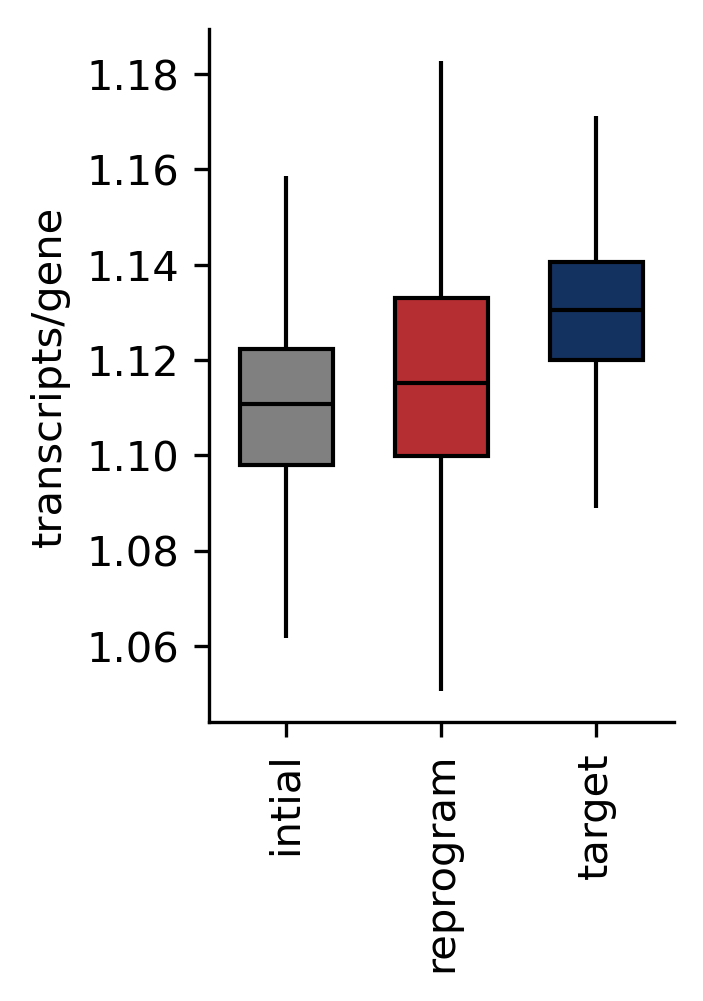

In [48]:
pdf = adata.obs.copy()
pdf['transcripts_per_gene'] = pdf['n_transcripts'] / pdf['n_genes']


pdf = pdf[~pdf['group'].isin(['bm_other'])]
pdf['group'] = pdf['group'].astype(str)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 3

palette = {
    'intial'  : "#808080",
    'reprogram' : "#CB181D", 
    'target' : "#08306B",
}

sns.boxplot(
    data=pdf,
    x='group',
    y='transcripts_per_gene',
    hue='group',
    showfliers=False,
    width=0.6,
    order=['intial', 'reprogram', 'target'],
    palette=palette,
    linecolor='k',
    capprops={'lw' : 0},
)

plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("transcripts/gene")
sns.despine()

# Summary by subgroup

In [49]:
transcript_read_threshold = 50
results = []

for group_name, group in adata.obs.groupby('subgroup', observed=True):
    cell_idx = group.index

    tmp = adata[cell_idx, :].copy()
    var = tmp.var.copy()

    var['reads_per_transcript'] = np.ravel(tmp.X.sum(axis=0))
    var['reads_per_gene'] = var.groupby('gene_name')['reads_per_transcript'].transform('sum')
    var['transctipt_pass'] = var['reads_per_transcript'] > transcript_read_threshold
    var['n_isoforms_per_gene'] = var.groupby('gene_name')['transctipt_pass'].transform('sum')

    filtered = var[
        (var['transctipt_pass'] == True) &
        (var['transcript_type'] == 'protein_coding')
    ]

    n_unique_genes = filtered['gene_name'].nunique()
    n_unique_transcripts = filtered['transcript_name'].nunique()


    genes_with_multiple = (
        filtered.groupby('gene_name')['transcript_name']
        .nunique()
        .ge(2)
        .sum()
    )
    
    # summary stats
    row = {
        'subgroup' : group_name,
        'n_unique_genes' : n_unique_genes,
        'n_unique_transcripts' : n_unique_transcripts,
        'genes_with_multiple' : genes_with_multiple,
        'avg_transcripts_per_gene' : n_unique_transcripts / n_unique_genes,
    }

    results.append(row)


results = pd.DataFrame(results)
print(results.to_string(index=False))

   subgroup  n_unique_genes  n_unique_transcripts  genes_with_multiple  avg_transcripts_per_gene
         C1            6490                  7759                  931                  1.195532
         C2            8623                 11378                 1911                  1.319494
         C3            9874                 14299                 2901                  1.448147
        CLP            3656                  4200                  431                  1.148796
        HSC            7609                 10286                 1934                  1.351820
       LMPP            6058                  7453                 1057                  1.230274
     intial           11515                 19244                 4571                  1.671211
progenitors           10442                 17069                 4127                  1.634649


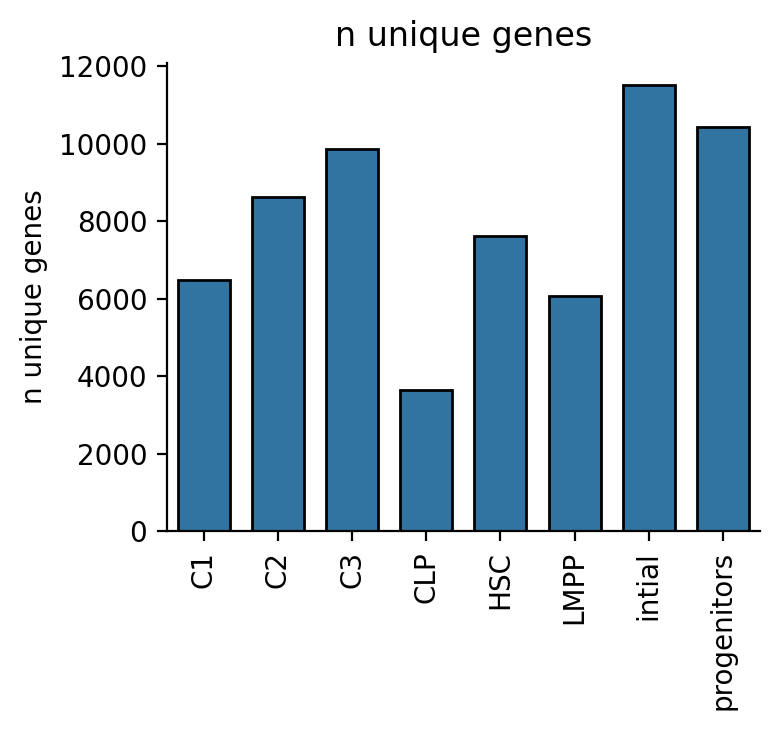

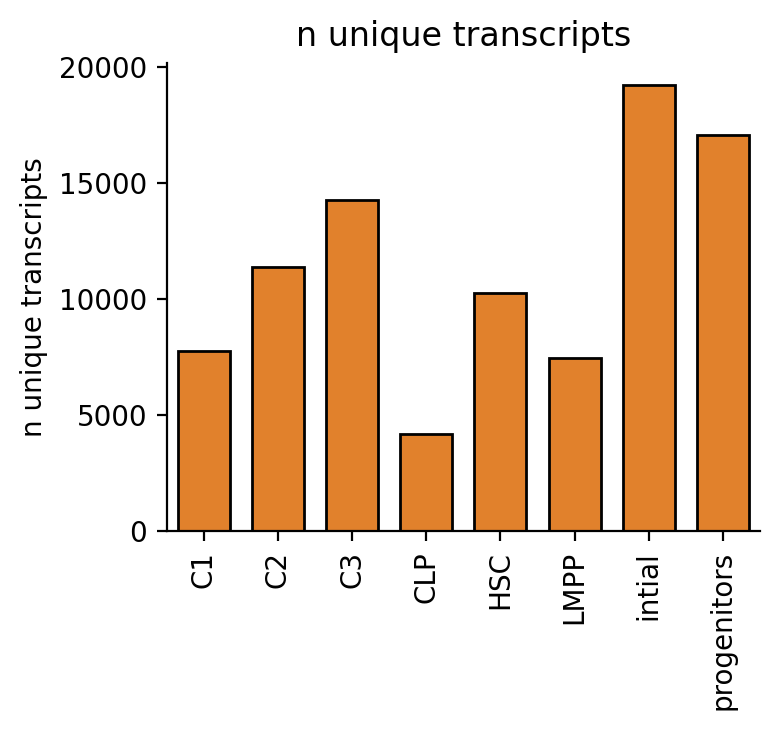

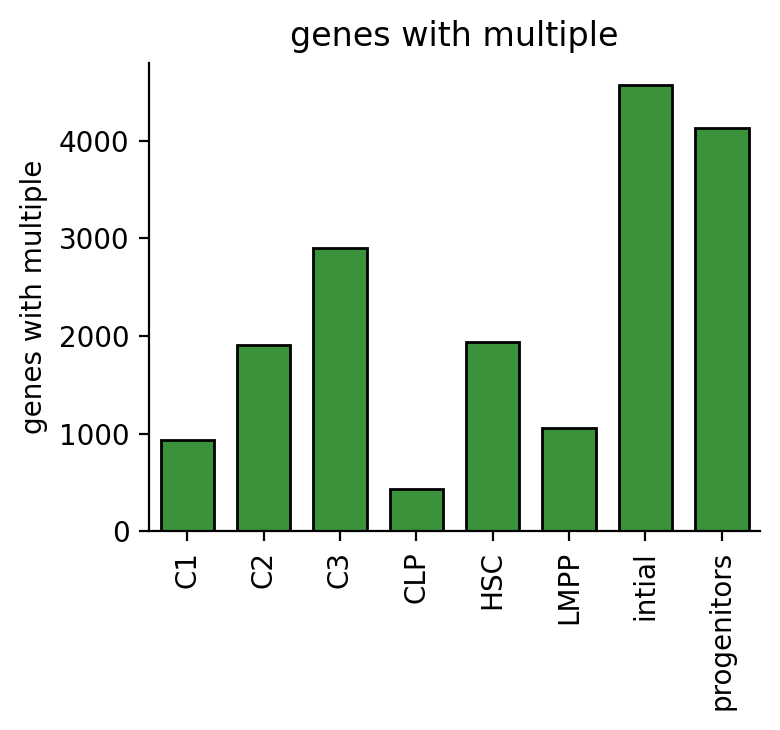

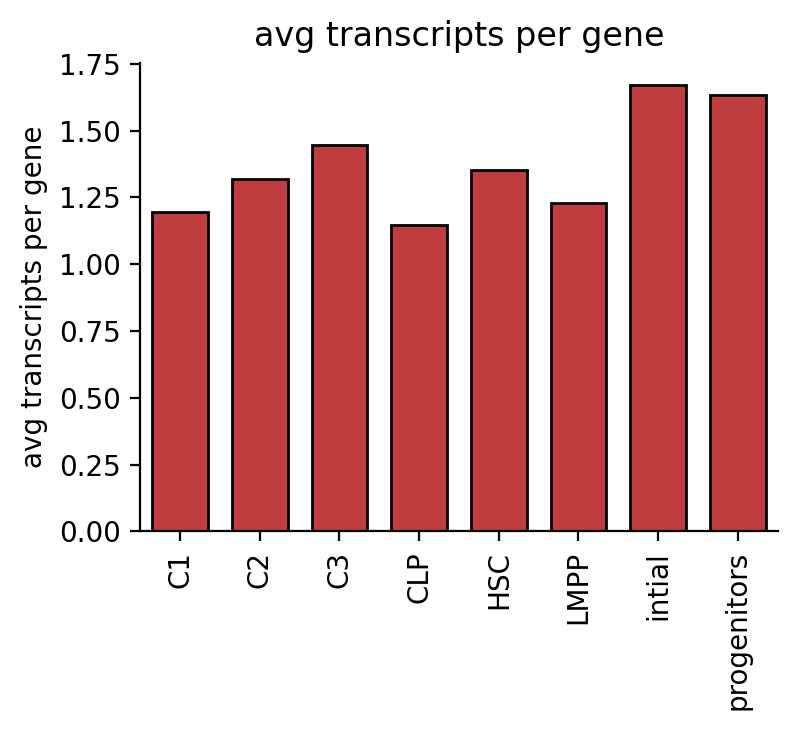

In [50]:
# Variables to plot
metrics = [
    'n_unique_genes',
    'n_unique_transcripts',
    'genes_with_multiple',
    'avg_transcripts_per_gene'
]

# Create a color palette with enough distinct colors
colors = sns.color_palette('tab10', n_colors=len(metrics))

# Plot each metric with a different color
for i, metric in enumerate(metrics):
    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 4, 3.75
    sns.barplot(
        data=results,
        x='subgroup',
        y=metric,
        ec='k',
        width=0.7,
        color=colors[i],
    )
    plt.title(metric.replace('_', ' '))
    plt.xlabel('')
    plt.ylabel(metric.replace('_', ' '))
    plt.xticks(rotation=90)
    plt.tight_layout()
    sns.despine()
    plt.show()
    # break